# 3 · What the data does not say

The first two notebooks asked *is the number right?* This one asks the harder question:
**does the number support the claim being made about it?**

Four cases, each a way of being confidently wrong:

1. A goodness-of-fit statistic that looks excellent and means almost nothing.
2. A pattern-search that finds structure in anything, including noise.
3. A model that scores 99.6% by reading the answer key.
4. A correlation that reverses sign because of how the data was collected.

Every one of these was a mistake actually made while building this project, caught by
something in the repository. They are reproduced here rather than described.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white", "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7", "font.size": 9,
})
BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#1baf7a"

## 1 · R² = 0.99, and predictions off by a fifth

The **Titius–Bode rule** claims planetary distances follow $a_n = 0.4 + 0.3\times 2^n$.
Those constants were written down in the 1770s, so comparing them against modern data is
a genuine out-of-sample test — nothing is fitted.

In [2]:
from orrery.statistics import titius_bode_fit, titius_bode_prediction

classical = titius_bode_prediction()

print(f"{'body':<10}{'actual':>10}{'rule':>10}{'error':>10}")
for body in classical.predicted_au:
    print(f"  {body:<8}{classical.actual_au[body]:>10.3f}{classical.predicted_au[body]:>10.3f}"
          f"{classical.relative_error(body):>+10.1%}")

others = classical.errors_excluding("neptune")
print()
print(f"worst error excluding Neptune: {max(abs(v) for v in others.values()):.1%}")
print(f"Neptune:                       {classical.relative_error('neptune'):+.1%}")

body          actual      rule     error
  mercury      0.387     0.400     +3.3%
  venus        0.723     0.700     -3.2%
  earth        1.000     1.000     -0.0%
  mars         1.524     1.600     +5.0%
  ceres        2.766     2.800     +1.2%
  jupiter      5.203     5.200     -0.1%
  saturn       9.537    10.000     +4.9%
  uranus      19.189    19.600     +2.1%
  neptune     30.070    38.800    +29.0%

worst error excluding Neptune: 5.0%
Neptune:                       +29.0%


Within 5% everywhere out to Uranus — including the **asteroid belt**, whose slot was
empty when the rule was published and where Ceres was found in 1801. Then Neptune breaks
it by 29%.

Now the trap. Suppose you had never heard of the rule and simply fitted a geometric
progression to the same distances, with two free parameters instead of zero.

In [3]:
fitted = titius_bode_fit()

print(f"fitted geometric progression:")
print(f"  R²             {fitted.fit.r_squared:.4f}")
print(f"  common ratio   {10 ** fitted.fit.slope:.4f}")
print(f"  worst error    {fitted.max_absolute_error:.1%}  (on {fitted.worst_body})")
print()
print(f"parameter-free classical rule, excluding Neptune:")
print(f"  worst error    {max(abs(v) for v in classical.errors_excluding('neptune').values()):.1%}")

fitted geometric progression:
  R²             0.9933
  common ratio   1.7328
  worst error    20.7%  (on mars)

parameter-free classical rule, excluding Neptune:
  worst error    5.0%


**R² = 0.993 while missing Mars by 21%.** Two fitted parameters do *worse* than the
18th-century constants.

The reason is structural. R² measures the fraction of *variance* explained, and when the
response climbs monotonically across two orders of magnitude, almost any increasing
curve explains nearly all of it. With nine points spanning 0.4 to 30 AU, a high R² is
close to uninformative.

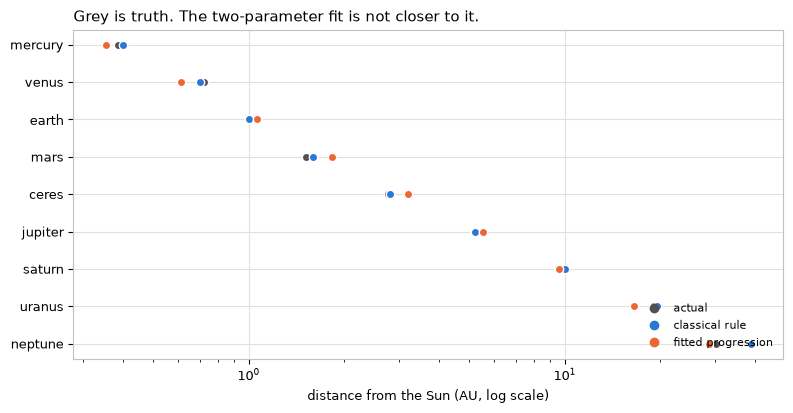

In [4]:
bodies = list(classical.predicted_au)
positions = np.arange(len(bodies))[::-1]

fig, ax = plt.subplots(figsize=(8.0, 4.2))
for body, y in zip(bodies, positions):
    actual = classical.actual_au[body]
    for value, colour, label in ((actual, "#52514e", "actual"),
                                 (classical.predicted_au[body], BLUE, "classical rule"),
                                 (fitted.predicted_au[body], ORANGE, "fitted progression")):
        ax.plot(value, y, marker="o", markersize=6, color=colour,
                markeredgecolor="white", markeredgewidth=1.0, zorder=3)
ax.set_xscale("log")
ax.set_yticks(positions); ax.set_yticklabels(bodies)
ax.set_xlabel("distance from the Sun (AU, log scale)")
ax.set_title("Grey is truth. The two-parameter fit is not closer to it.", loc="left")
for colour, label in ((("#52514e"), "actual"), (BLUE, "classical rule"), (ORANGE, "fitted progression")):
    ax.plot([], [], marker="o", linestyle="none", color=colour, label=label)
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

**The lesson generalises well beyond astronomy:** report per-point errors alongside any
aggregate goodness-of-fit. The aggregate can hide a model that is wrong everywhere in
the same direction.

## 2 · A pattern-finder that finds patterns in noise

Orbital **resonances** — period ratios close to simple fractions like 3:2 — are real
physics. The obvious way to search for them is Python's `Fraction.limit_denominator`,
which finds the closest fraction with a bounded denominator.

That bounds only the *denominator*. Watch what happens.

In [5]:
from fractions import Fraction
from orrery.elements import PLANETS
from orrery.statistics import best_rational_approximation

ratio = PLANETS["pluto"].period_days / PLANETS["mars"].period_days
naive = Fraction(ratio).limit_denominator(10)
bounded = best_rational_approximation(ratio, max_integer=13)

print(f"Pluto's period is {ratio:.4f} times Mars's.")
print()
print(f"  bounding the denominator only:  {naive.numerator}:{naive.denominator}"
      f"   error {abs(ratio - naive.numerator / naive.denominator) / ratio:.2e}"
      f"   order {abs(naive.numerator - naive.denominator)}")
bounded_error = abs(ratio - bounded.numerator / bounded.denominator) / ratio
print(f"  bounding both integers:         {bounded.numerator}:{bounded.denominator}"
      f"   error {bounded_error:.2e}"
      f"   order {abs(bounded.numerator - bounded.denominator)}")
print()
print(f"The bounded search's {bounded_error:.0%} error is the *right* answer: there simply is")
print("no low-order commensurability between Mars and Pluto, so a search restricted to")
print("small integers correctly reports nothing. The unbounded one manufactures a match.")

Pluto's period is 131.9007 times Mars's.

  bounding the denominator only:  1319:10   error 5.12e-06   order 1309
  bounding both integers:         13:1   error 9.01e-01   order 12

The bounded search's 90% error is the *right* answer: there simply is
no low-order commensurability between Mars and Pluto, so a search restricted to
small integers correctly reports nothing. The unbounded one manufactures a match.


`1319:10` matches to five decimal places and means **nothing**. A 1309th-order resonance
is not a resonance; resonance strength falls off sharply with order. With the numerator
unbounded, *every* real number has a close rational approximation — the search was
guaranteed to succeed before it started.

Bounding both integers, only the commensurabilities the literature actually discusses
survive.

In [6]:
from orrery.elements import PLANET_NAMES
from orrery.statistics import find_resonances

for resonance in find_resonances((*PLANET_NAMES, "pluto"), tolerance=0.02):
    print(f"  {resonance.outer:<9} : {resonance.inner:<9} = {resonance.p:>2}:{resonance.q:<2}"
          f"   ratio {resonance.period_ratio:.4f}   off by {resonance.relative_error:.2%}"
          f"   order {resonance.order}")

  earth     : venus     = 13:8    ratio 1.6255   off by 0.03%   order 5
  pluto     : neptune   =  3:2    ratio 1.5045   off by 0.30%   order 1
  saturn    : jupiter   =  5:2    ratio 2.4816   off by 0.74%   order 3
  uranus    : jupiter   =  7:1    ratio 7.0830   off by 1.19%   order 6
  mars      : earth     = 13:7    ratio 1.8808   off by 1.28%   order 6
  pluto     : uranus    =  3:1    ratio 2.9513   off by 1.62%   order 2
  mars      : venus     =  3:1    ratio 3.0573   off by 1.91%   order 2
  neptune   : uranus    =  2:1    ratio 1.9616   off by 1.92%   order 1


Venus–Earth 13:8, Neptune–Pluto 3:2, Jupiter–Saturn 5:2, Uranus–Neptune 2:1. These are
the famous ones, and they fall out on their own.

### But are they remarkable?

Popular writing treats these near-commensurabilities as evidence of deep structure. That
is a testable claim, so let us test it against an explicit null: **the same number of
planets, spanning the same radial range, with random spacing**.

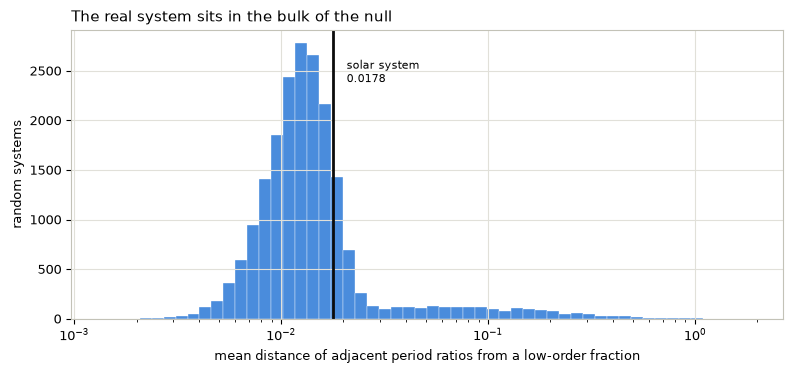

observed statistic  0.01777
null median         0.01290
p-value             0.7911

no evidence against the null (p = 0.791); note the result depends on how the null was constructed


In [7]:
from orrery.statistics import monte_carlo_resonance_test

result = monte_carlo_resonance_test(trials=20_000)

fig, ax = plt.subplots(figsize=(8.0, 3.8))
positive = result.null_samples[result.null_samples > 0]
bins = np.logspace(np.log10(positive.min() * 0.8), np.log10(positive.max() * 1.2), 55)
ax.hist(positive, bins=bins, color=BLUE, alpha=0.85, edgecolor="white", linewidth=0.3)
ax.axvline(result.observed, color="#0b0b0b", linewidth=2)
ax.annotate(f"solar system\n{result.observed:.4f}", (result.observed, ax.get_ylim()[1] * 0.9),
            textcoords="offset points", xytext=(10, 0), fontsize=8, va="top")
ax.set_xscale("log")
ax.set_xlabel("mean distance of adjacent period ratios from a low-order fraction")
ax.set_ylabel("random systems")
ax.set_title("The real system sits in the bulk of the null", loc="left")
plt.tight_layout(); plt.show()

print(f"observed statistic  {result.observed:.5f}")
print(f"null median         {result.null_median:.5f}")
print(f"p-value             {result.p_value:.4f}")
print()
print(result.interpretation)

**p = 0.79.** The real solar system's adjacent period ratios are, if anything, slightly
*farther* from low-order fractions than a random system of the same size and extent.

This is a negative result and it is reported as one. The p-value also depends on how the
null was built — a different null would give a different number — which is why the null
is stated explicitly rather than left implicit.

## 3 · A classifier that scores 99.6% and has learned nothing

The Kepler Objects of Interest table lists every transit signal the mission flagged,
each later adjudicated as a real planet or a false positive. A perfect classification
dataset — with a trap in it.

In [8]:
from orrery.koi import LEAKY_FEATURES, PHYSICAL_FEATURES, koi_cache_path, load_koi_table
from orrery.models import evaluate_koi_leakage

HAVE_KOI = koi_cache_path().exists()

if HAVE_KOI:
    table = load_koi_table()
    print(f"{len(table):,} objects — {int(table.labels.sum()):,} confirmed planets, "
          f"{int((1 - table.labels).sum()):,} false positives")
    print()
    print("Physical features — measurements taken before anyone decided what it was:")
    print("  " + ", ".join(PHYSICAL_FEATURES))
    print()
    print("And these, sitting in the same table with unremarkable names:")
    for name in LEAKY_FEATURES:
        print(f"  {name}")
else:
    print("No KOI snapshot. Run:  python scripts/fetch_exoplanets.py --koi")

7,586 objects — 2,747 confirmed planets, 4,839 false positives

Physical features — measurements taken before anyone decided what it was:
  koi_period, koi_duration, koi_depth, koi_prad, koi_teq, koi_insol, koi_impact, koi_model_snr, koi_steff, koi_slogg, koi_srad, koi_kepmag

And these, sitting in the same table with unremarkable names:
  koi_score
  koi_fpflag_nt
  koi_fpflag_ss
  koi_fpflag_co
  koi_fpflag_ec


`koi_fpflag_nt` is "not transit-like". `koi_fpflag_ss` is "stellar eclipse".
`koi_fpflag_co` is "centroid offset". These are the **reasons a signal was rejected** —
the output of the labelling process, not an input to it.

Training on them is circular. Here is what that circularity is worth.

In [9]:
if HAVE_KOI:
    leakage = evaluate_koi_leakage(load_koi_table())
    print(f"trained and tested on the same {leakage.sample_size:,} rows, same split:")
    print()
    print(f"  {leakage.physical.name:<28} accuracy {leakage.physical.accuracy:.4f}"
          f"   AUC {leakage.physical.roc_auc:.4f}")
    print(f"  {leakage.with_leakage.name:<28} accuracy {leakage.with_leakage.accuracy:.4f}"
          f"   AUC {leakage.with_leakage.roc_auc:.4f}")
    print()
    print(f"  the flags buy {leakage.accuracy_gap:+.2%} accuracy and are worth nothing")
    print()
    print("  where that came from:")
    for name, value in leakage.leaky_importance.items():
        print(f"    {name:<20} {value:+.4f} AUC")
else:
    print("skipped — no KOI snapshot")

trained and tested on the same 7,326 rows, same split:

  Physical features only       accuracy 0.9322   AUC 0.9789
  With leaked vetting flags    accuracy 0.9955   AUC 0.9989

  the flags buy +6.32% accuracy and are worth nothing

  where that came from:
    koi_fpflag_ss        +0.0641 AUC
    koi_fpflag_co        +0.0250 AUC
    koi_fpflag_nt        +0.0131 AUC
    koi_score            +0.0112 AUC
    koi_fpflag_ec        +0.0006 AUC


**93.2% → 99.6%.** The first number is a genuinely useful model that tells a planet from
an eclipsing binary using the light curve and the host star. The second has learned to
read the answer key.

This is easy to walk into by accident: the columns sit in the same table, have
unremarkable names, and improve every metric you look at. The defence is not cleverness
— it is **partitioning the columns by what was knowable when**, which
[`orrery/koi.py`](../orrery/koi.py) does explicitly.

## 4 · A correlation that reverses because of how the data was gathered

The **Hertzsprung–Russell diagram** plots stellar colour against intrinsic brightness.
Its defining feature is the main sequence: redder stars are cooler and fainter, so
colour and absolute magnitude should be **positively** correlated.

Let us check that against 120,000 real Gaia stars.

In [10]:
from orrery.gaia import gaia_cache_path, load_gaia_sample

HAVE_GAIA = gaia_cache_path().exists()

if HAVE_GAIA:
    stars = load_gaia_sample()
    absolute = stars.absolute_g()
    good = np.isfinite(absolute) & np.isfinite(stars.bp_rp)
    correlation = np.corrcoef(stars.bp_rp[good], absolute[good])[0, 1]

    print(f"{int(good.sum()):,} stars with a usable distance")
    print(f"correlation of colour with absolute magnitude:  {correlation:+.3f}")
    print()
    print("Expected: positive, the main sequence.  Observed: negative.")
else:
    print("No Gaia snapshot. Run:  python scripts/fetch_gaia.py")

119,262 stars with a usable distance
correlation of colour with absolute magnitude:  -0.494

Expected: positive, the main sequence.  Observed: negative.


The sign is wrong. This is exactly the failure that broke the project's first HR-diagram
test, and the instinct — that something is broken in the distance calculation — is
wrong.

Split by distance and the mechanism appears.

shell (pc)        stars     corr   faintest M_G
     0–25           797   +0.875         +11.88
    25–50         3,388   +0.504          +6.55
    50–100       11,407   +0.090          +5.11
   100–200       23,696   -0.268          +3.62
   200–500       46,889   -0.374          +2.11
   500–6000      33,085   -0.139          +0.13


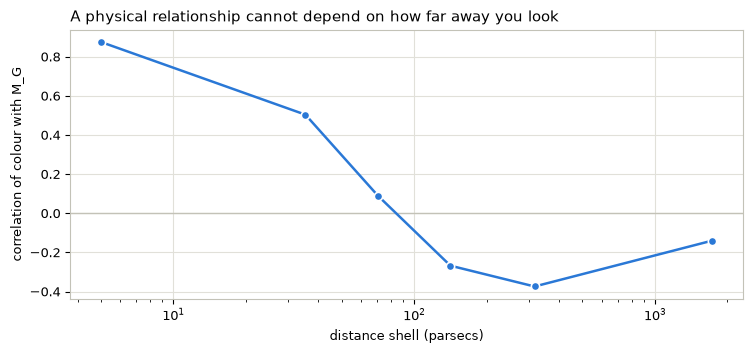

In [11]:
if HAVE_GAIA:
    distance = stars.distance_parsec()
    shells = [(0, 25), (25, 50), (50, 100), (100, 200), (200, 500), (500, 6000)]

    print(f"{'shell (pc)':<14}{'stars':>9}{'corr':>9}{'faintest M_G':>15}")
    centres, correlations = [], []
    for low, high in shells:
        mask = good & (distance >= low) & (distance < high)
        c = np.corrcoef(stars.bp_rp[mask], absolute[mask])[0, 1]
        centres.append(np.sqrt(max(low, 1) * high)); correlations.append(c)
        print(f"  {low:>4}–{high:<7}{int(mask.sum()):>9,}{c:>+9.3f}{absolute[mask].max():>+15.2f}")

    fig, ax = plt.subplots(figsize=(7.6, 3.6))
    ax.axhline(0, color="#c3c2b7", linewidth=1)
    ax.plot(centres, correlations, color=BLUE, linewidth=1.8, marker="o", markersize=6,
            markeredgecolor="white", markeredgewidth=1.2)
    ax.set_xscale("log")
    ax.set_xlabel("distance shell (parsecs)")
    ax.set_ylabel("correlation of colour with M_G")
    ax.set_title("A physical relationship cannot depend on how far away you look", loc="left")
    plt.tight_layout(); plt.show()

Nearby, the main sequence is textbook-clean: **+0.88**, with stars visible down to
absolute magnitude +11.9. As distance grows, the survey's brightness limit progressively
cuts off the faint end — by 200 pc nothing fainter than $M_G = +2$ is bright enough to
appear at all — until only giants remain. Giants are red **and** luminous, which is the
opposite of the main-sequence trend, so the correlation flips.

This is **Malmquist bias**, and the test now asserts it directly rather than working
around it: the main sequence within 25 parsecs, and the sign flip further out.

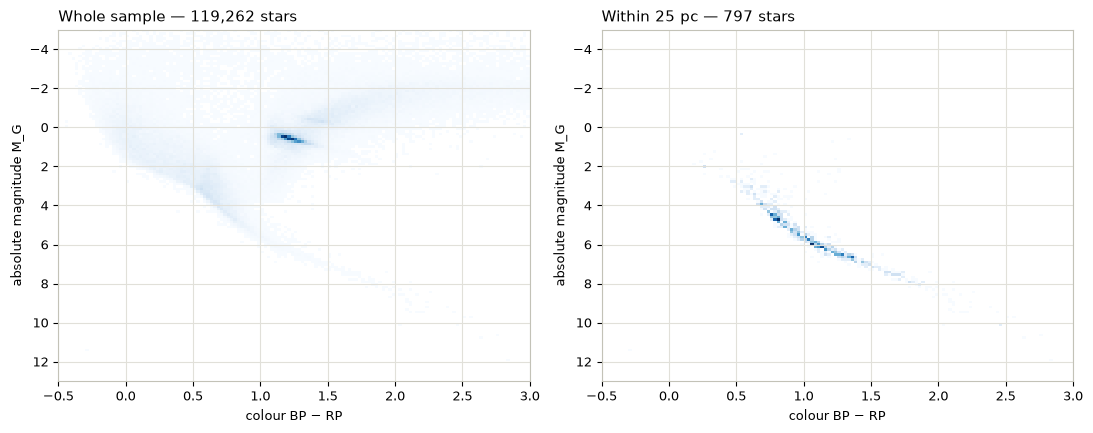

In [12]:
if HAVE_GAIA:
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))
    for ax, mask, title in (
        (axes[0], good, f"Whole sample — {int(good.sum()):,} stars"),
        (axes[1], good & (distance < 25), f"Within 25 pc — {int((good & (distance < 25)).sum()):,} stars"),
    ):
        ax.hist2d(stars.bp_rp[mask], absolute[mask], bins=(140, 140),
                  range=[[-0.5, 3.0], [-5, 13]], cmap="Blues", cmin=1)
        ax.set_ylim(13, -5)
        ax.set_xlabel("colour BP − RP"); ax.set_ylabel("absolute magnitude M_G")
        ax.set_title(title, loc="left")
    plt.tight_layout(); plt.show()

Left: the main sequence is there, but a huge cloud of giants sits above it and dominates
the statistics. Right: the same plot for a nearly volume-limited sample, and the main
sequence stands alone.

**Same data. Same code. Opposite conclusion**, depending entirely on which stars the
telescope could see.

## The common thread

| Case | The comfortable reading | What was actually true |
|---|---|---|
| Titius–Bode | R² = 0.99, an excellent fit | Individual predictions off by 21% |
| Resonances | Many commensurabilities found | The search finds them in anything |
| Kepler classifier | 99.6% accuracy | The model read the answer key |
| HR diagram | The relationship reverses with distance | The *sample* changes with distance |

None of these are exotic statistical failures. All four are what happens when a number
gets reported without asking what could have produced it other than the effect you were
hoping for.

The defences are unglamorous and they work: report per-point errors beside aggregates,
state your null hypothesis, partition features by what was knowable when, and vary the
thing you did not intend to measure — step size, distance cut, sample limit — to see
whether your result moves with it.